## Bài tập thực hành 3 - 2026
Bài thực hành 3 - 2026
Phân loại ảnh sử dụng Mạng tích chập

Link google colab: https://drive.google.com/file/d/1OAZK08O3AYoNvmbq7JIBg5Oknp6cJgzn/view?usp=sharing

---
### Thông tin sinh viên
- **MSSV**: 24521901
- **Họ và tên**: Trần Quang Trường
---


### 0. Mô tả bài toán

 Sử dụng tập dữ liệu HoaVietNam2026
- Tập train: chia thành 2 tập mới là train và val theo tỉ lệ 8:2
- Tập test: vẫn giữ nguyên

---

#### 0.1 Đọc dữ liệu
Trước khi thực hiện yêu cầu bài tập, ta sẽ đọc tập dữ liệu train và test từ `HoaVietNam2026.zip`

Để truy cập tập dữ liệu, ta sẽ mount tới Google Drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import các thư viện cần thiết


In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras import models, layers
from tensorflow.keras.optimizers import Adam, SGD, Lion
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping


Vì cấu trúc tập train và test là như nhau nên ta sẽ tạo một hàm để có thể extract dữ liệu từ thư mục sau khi giải nén.

In [3]:
def load_images_from_folder(folder_dir, img_row, img_col):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder_dir))

    for label, class_name in enumerate(class_names):
        class_folder = os.path.join(folder_dir, class_name)
        if os.path.isdir(class_folder):
            for filename in os.listdir(class_folder):
                img_path = os.path.join(class_folder, filename)
                img = cv2.imread(img_path)
                if img is not None:
                    img = cv2.resize(img, (img_row, img_col))
                    images.append(img)
                    labels.append(label)

    return images, labels, class_names

In [4]:
train_folder_dir  = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026/train'
test_folder_dir   = '/content/drive/MyDrive/[CS231.Q21.KHTN] - Computer Vision 01/HoaVietNam2026/test'

img_row, img_col = 128, 128

X_train_val, y_train_val, class_names = load_images_from_folder(train_folder_dir, img_row, img_col)
X_test, y_test, _ = load_images_from_folder(test_folder_dir, img_row, img_col)

Chia tập dữ liệu với tỉ lệ 8:2

In [5]:
# Set seed for all
np.random.seed(42)

In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42)

In [7]:
X_train = np.array(X_train)
X_val = np.array(X_val)
X_test = np.array(X_test)

X_train = X_train.reshape((len(X_train), img_row, img_col, 3)).astype ('float32') / 255
X_val = X_val.reshape((len(X_val), img_row, img_col, 3)).astype('float32') / 255
X_test = X_test.reshape((len(X_test), img_row, img_col, 3)).astype('float32') / 255

y_train = to_categorical(y_train)
y_val = to_categorical(y_val)
y_test = to_categorical(y_test)

print(f"Kích thước tập train: {X_train.shape}, {y_train.shape}")
print(f"Kích thước tập validation: {X_val.shape}, {y_val.shape}")
print(f"Kích thước tập test: {X_test.shape}, {y_test.shape}")

Kích thước tập train: (200, 128, 128, 3), (200, 7)
Kích thước tập validation: (50, 128, 128, 3), (50, 7)
Kích thước tập test: (77, 128, 128, 3), (77, 7)


---

#### 0.2 Xây dựng kiến trúc dựa trên kiến trúc của mạng LeNet-5
- Dựa trên kiến trục mạng LeNet-5 với các tham số mới:


In [8]:
def build_and_compile_model(opt):
    model = models.Sequential()

    model.add(layers.Conv2D(6,(3,3), activation='relu', input_shape=(128,128, 3), padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(16, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Flatten())
    model.add(layers.Dense(120, activation='relu'))
    model.add(layers.Dense(84, activation='relu'))
    model.add(layers.Dense(7, activation='softmax'))

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    return model

---

### 1. Yêu cầu 1
- Thực nghiệm với 3 optimizer: Adam, SGD và Lion
để đánh giá optimizer nào phù hợp nhất.
- Các tham số khác cố định như sau:
  - Learning_rate=0.00001
  - loss: 'categorical_crossentropy',
  - metrics='accuracy'
  - batch_size=8
  - epochs=15,
- Đánh giá kết quả của 3 mô hình trên tập Test

---

#### 1.1 Xây dựng model với 3 optimizer

In [9]:
opt_name = ['Adam', 'SGD', 'Lion']

adam = Adam(learning_rate=0.00001)
sgd = SGD(learning_rate=0.00001)
lion = Lion(learning_rate=0.00001)

model_with_adam = build_and_compile_model(adam)
model_with_sgd = build_and_compile_model(sgd)
model_with_lion = build_and_compile_model(lion)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### 1.2 Huấn luyện 3 model
Với mỗi model, ta train và evaluate để lấy accuracy đánh giá.


In [10]:
test_accs = []
test_losses = []

for model in [model_with_adam, model_with_sgd, model_with_lion]:
    print(f"Huấn luyện với optimizer {model.optimizer}")
    model.fit(X_train, y_train, epochs=15, batch_size=8, validation_data=(X_val, y_val))
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=2)

    print(f"Test Accuracy: {test_accuracy}")
    print(f"Test Loss: {test_loss}")

    test_accs.append(test_accuracy)
    test_losses.append(test_loss)

Huấn luyện với optimizer <keras.src.optimizers.adam.Adam object at 0x7ecb6e25cbf0>
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.1700 - loss: 1.9591 - val_accuracy: 0.1400 - val_loss: 1.9827
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2000 - loss: 1.9078 - val_accuracy: 0.1200 - val_loss: 1.9542
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2150 - loss: 1.8769 - val_accuracy: 0.1600 - val_loss: 1.9240
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3750 - loss: 1.8380 - val_accuracy: 0.1800 - val_loss: 1.8966
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3900 - loss: 1.8014 - val_accuracy: 0.2600 - val_loss: 1.8659
Epoch 6/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3850 - loss: 1.7647 - val_accuracy: 0.3400 - val_loss: 1.8385
Epoch 7/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4800 - loss: 1.7219 - val_accuracy: 0.3200 - val_loss: 1.8135
Epoch 8/15
25/25 ━━━━━━━━━━━━━━━━

#### 1.3 Đánh giá kết quả của 3 mô hình trên tập Test

Tạo bảng so sánh test accuracy và test loss

In [11]:
table = np.array([test_accs, test_losses])
table = np.transpose(table)

df = pd.DataFrame(table, columns=['Accuracy', 'Loss'], index=opt_name)
df

,Accuracy,Loss
Adam,0.441558,1.621748
SGD,0.155844,1.997842
Lion,0.467532,1.221163


$\rightarrow$ Từ bảng so sánh ta thấy được optimizer Lion cho kết quả acc tốt nhất với 0.4675


---

### 2. Yêu cầu 2

Với optimizer hiệu quả nhất trong Yêu cầu 1. Hãy thực
hiện huấn luyện mô hình có sử dụng:
- ReduceLROnPlateau
- EarlyStopping
- Hiển thị biểu đồ cho biết Độ chính xác và loss trong quá trình
huấn luyện

---

Ta sẽ train model khi sử dụng ReduceLROnPlateau và EarlyStopping với optimizer Lion.

In [12]:
best_opt = Lion(learning_rate=0.00001)
best_model = build_and_compile_model(best_opt)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-9)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = best_model.fit(X_train, y_train, epochs=100, batch_size=8, validation_data=(X_val, y_val), callbacks=[reduce_lr, early_stopping])

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.1950 - loss: 1.9006 - val_accuracy: 0.2000 - val_loss: 1.8270 - learning_rate: 1.0000e-05
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3850 - loss: 1.7097 - val_accuracy: 0.3400 - val_loss: 1.6761 - learning_rate: 1.0000e-05
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4750 - loss: 1.5361 - val_accuracy: 0.5000 - val_loss: 1.5082 - learning_rate: 1.0000e-05
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5650 - loss: 1.3687 - val_accuracy: 0.5400 - val_loss: 1.3599 - learning_rate: 1.0000e-05
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6100 - loss: 1.2202 - val_accuracy: 0.5600 - val_loss: 1.2444 - learning_rate: 1.0000e-05
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6800 - loss: 1.0900 - val_accuracy: 0.6400 - val_loss: 1.1347 - learning_rate: 1.0000e-05
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7150 - loss: 0.9

In [13]:
test_loss, test_accuracy = best_model.evaluate(X_test, y_test, verbose=2)

print(test_accuracy)

3/3 - 1s - 285ms/step - accuracy: 0.5974 - loss: 1.1936
0.5974025726318359


$\rightarrow$ Kết quả huấn luyện cho ra acc = 0.5974

Hiển thị biểu đồ cho biết Độ chính xác và loss trong quá trình
huấn luyện:

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


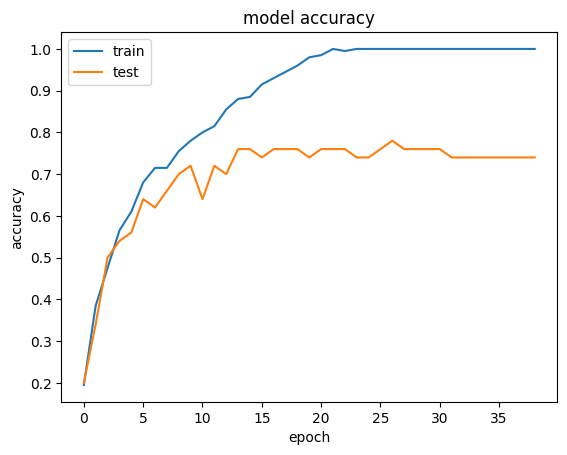

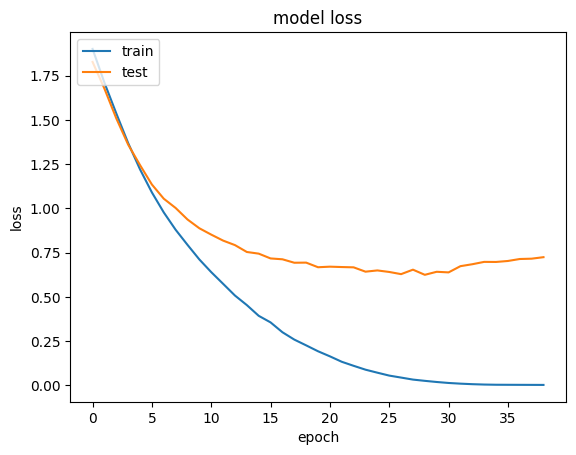

In [14]:
# list all data in history
print(history.history.keys())
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()